<a href="https://colab.research.google.com/github/Solo7602/web/blob/4lab/lab4_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ratings: (100836, 4)
Movies: (9742, 3)

=== 2. Базовые показатели эффективности ===

2.1 Среднее количество просмотров фильма:
Mean = 10.37, Median = 3.00

2.2 Топ-10 жанров по популярности:
genres_list
Drama        41928
Comedy       39053
Action       30635
Thriller     26452
Adventure    24161
Romance      18124
Sci-Fi       17243
Crime        16681
Fantasy      11834
Children      9208
dtype: int64

2.3 Топ-10 самых популярных фильмов:
                                       title  n_ratings
0                        Forrest Gump (1994)        329
1           Shawshank Redemption, The (1994)        317
2                        Pulp Fiction (1994)        307
3           Silence of the Lambs, The (1991)        279
4                         Matrix, The (1999)        278
5  Star Wars: Episode IV - A New Hope (1977)        251
6                       Jurassic Park (1993)        238
7                          Braveheart (1995)        237
8          Terminator 2: Judgment Day (1991)        

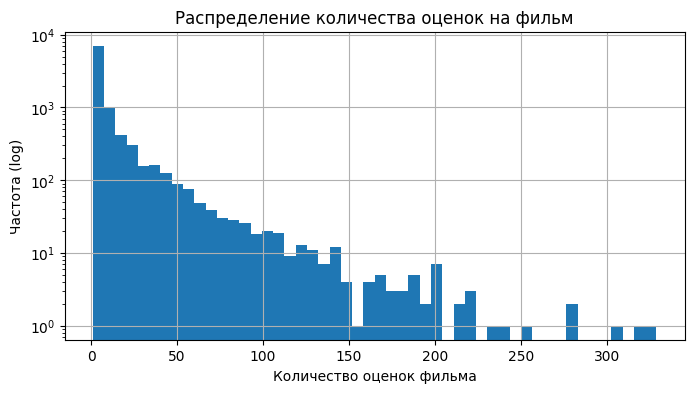

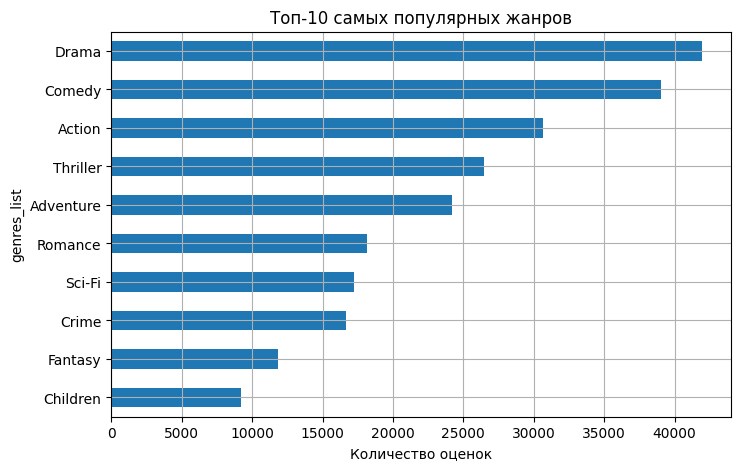

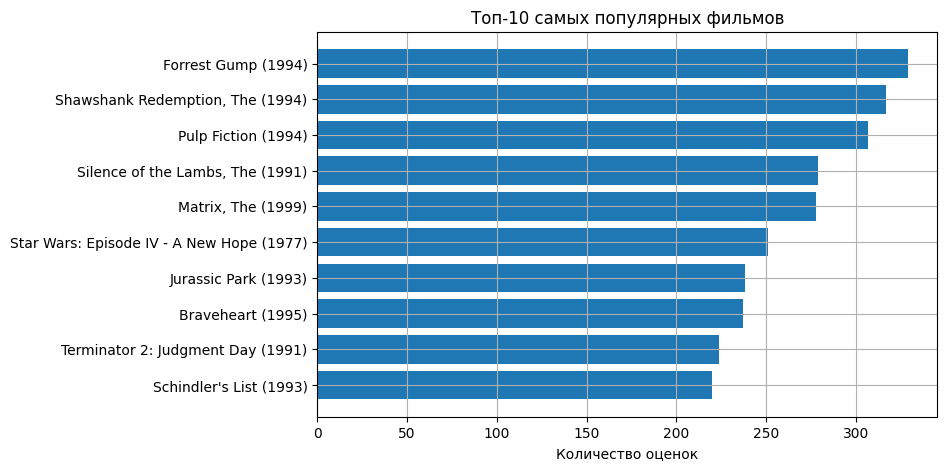


Рекомендации для userId=432:
Truman Show, The (1998) — score=301.335
Batman Begins (2005) — score=292.852
Incredibles, The (2004) — score=288.193
Indiana Jones and the Temple of Doom (1984) — score=281.505
Saving Private Ryan (1998) — score=280.736
Men in Black (a.k.a. MIB) (1997) — score=279.948
Groundhog Day (1993) — score=279.869
Back to the Future (1985) — score=279.656
Reservoir Dogs (1992) — score=277.435
Ferris Bueller's Day Off (1986) — score=275.563

RMSE (item-based): 3.1462
MAP@10: 0.0000

=== Анализ влияния факторов на точность модели ===

1. Количество оценок фильма:
   Популярные фильмы имеют более стабильные рекомендации,
   так как для них больше пользовательских данных.

2. Жанры:
   Жанровая схожесть влияет на рекомендации косвенно —
   через схожие паттерны пользовательских оценок.

3. Оценки пользователя:
   Фильмы с высокими оценками пользователя сильнее
   влияют на формирование рекомендаций.

4. Матричная факторизация:
   SVD позволяет выявлять скрытые предпочте

In [6]:
import os
import zipfile
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error

# ======================
# Настройки
# ======================
DATA_DIR = "data"
ZIP_URL = "http://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ======================
# Скачивание и распаковка
# ======================
os.makedirs(DATA_DIR, exist_ok=True)
zip_path = os.path.join(DATA_DIR, "ml-latest-small.zip")

if not os.path.exists(zip_path):
    print("Downloading dataset...")
    r = requests.get(ZIP_URL)
    with open(zip_path, "wb") as f:
        f.write(r.content)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(DATA_DIR)

DATA_PATH = os.path.join(DATA_DIR, "ml-latest-small")

# ======================
# Загрузка данных
# ======================
ratings = pd.read_csv(os.path.join(DATA_PATH, "ratings.csv"))
movies = pd.read_csv(os.path.join(DATA_PATH, "movies.csv"))

print("Ratings:", ratings.shape)
print("Movies:", movies.shape)

print("\n=== 2. Базовые показатели эффективности ===")

# 2.1 Среднее количество просмотров (оценок) каждого фильма
ratings_per_movie = ratings.groupby("movieId").size()
mean_views = ratings_per_movie.mean()
median_views = ratings_per_movie.median()

print(f"\n2.1 Среднее количество просмотров фильма:")
print(f"Mean = {mean_views:.2f}, Median = {median_views:.2f}")

# 2.2 Популярность жанров
movies["genres_list"] = movies["genres"].str.split("|")

genre_stats = (
    ratings.merge(movies[["movieId", "genres_list"]], on="movieId")
           .explode("genres_list")
           .groupby("genres_list")
           .size()
           .sort_values(ascending=False)
)

print("\n2.2 Топ-10 жанров по популярности:")
print(genre_stats.head(10))

# 2.3 Топ-10 фильмов по количеству оценок
top10_movies = (
    ratings_per_movie
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .merge(movies[["movieId", "title"]], on="movieId")
)

print("\n2.3 Топ-10 самых популярных фильмов:")
print(top10_movies[["title", 0]].rename(columns={0: "n_ratings"}))

print("\n=== 3. Визуализация результатов ===")

# Распределение просмотров
plt.figure(figsize=(8, 4))
plt.hist(ratings_per_movie.values, bins=50, log=True)
plt.xlabel("Количество оценок фильма")
plt.ylabel("Частота (log)")
plt.title("Распределение количества оценок на фильм")
plt.grid()
plt.show()

# Топ жанров
plt.figure(figsize=(8, 5))
genre_stats.head(10).sort_values().plot(kind="barh")
plt.xlabel("Количество оценок")
plt.title("Топ-10 самых популярных жанров")
plt.grid()
plt.show()

# Топ-10 фильмов
plt.figure(figsize=(8, 5))
plt.barh(top10_movies["title"], top10_movies[0])
plt.xlabel("Количество оценок")
plt.title("Топ-10 самых популярных фильмов")
plt.gca().invert_yaxis()
plt.grid()
plt.show()


# ======================
# User–Item матрица
# ======================
user_item_matrix = ratings.pivot_table(
    index="userId",
    columns="movieId",
    values="rating",
    fill_value=0
)

# ======================
# Item-based cosine similarity
# ======================
item_similarity = cosine_similarity(user_item_matrix.T)
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=user_item_matrix.columns,
    columns=user_item_matrix.columns
)

# ======================
# Item-based рекомендации
# ======================
def recommend_item_based(user_id, top_k=10):
    if user_id not in user_item_matrix.index:
        return []

    user_ratings = user_item_matrix.loc[user_id]
    rated_movies = user_ratings[user_ratings > 0]

    scores = defaultdict(float)

    for movie_id, rating in rated_movies.items():
        for similar_movie, sim in item_similarity_df[movie_id].items():
            if user_ratings.get(similar_movie, 0) == 0:
                scores[similar_movie] += sim * rating

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return ranked[:top_k]

# ======================
# Пример рекомендаций
# ======================
example_user = ratings["userId"].sample(1, random_state=RANDOM_STATE).iloc[0]
print(f"\nРекомендации для userId={example_user}:")

for movie_id, score in recommend_item_based(example_user):
    title = movies[movies["movieId"] == movie_id]["title"].values[0]
    print(f"{title} — score={score:.3f}")

# ======================
# Оценка качества: RMSE
# ======================
def predict_rating(user_id, movie_id):
    if movie_id not in item_similarity_df.columns:
        return ratings["rating"].mean()

    similar_movies = item_similarity_df[movie_id]
    user_ratings = user_item_matrix.loc[user_id]

    mask = user_ratings > 0
    if not mask.any():
        return ratings["rating"].mean()

    num = np.sum(similar_movies[mask.index] * user_ratings)
    den = np.sum(np.abs(similar_movies[mask.index]))

    return num / den if den != 0 else ratings["rating"].mean()

# тестовая выборка
test = ratings.sample(frac=0.2, random_state=RANDOM_STATE)

y_true, y_pred = [], []

for _, row in test.iterrows():
    y_true.append(row["rating"])
    y_pred.append(predict_rating(row["userId"], row["movieId"]))

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"\nRMSE (item-based): {rmse:.4f}")

# ======================
# MAP@K
# ======================
def apk(actual, predicted, k=10):
    score = 0.0
    hits = 0.0

    for i, p in enumerate(predicted[:k]):
        if p in actual and p not in predicted[:i]:
            hits += 1
            score += hits / (i + 1)

    return score / min(len(actual), k) if actual else 0.0

def mapk(actual, predicted, k=10):
    return np.mean([apk(a, p, k) for a, p in zip(actual, predicted)])

# ground truth: фильмы с рейтингом >= 3
gt = test[test["rating"] >= 3].groupby("userId")["movieId"].apply(list)

actual_list = []
predicted_list = []

for user_id, actual_movies in gt.items():
    recs = recommend_item_based(user_id, top_k=10)
    predicted_movies = [m for m, _ in recs]
    actual_list.append(actual_movies)
    predicted_list.append(predicted_movies)

mapk_score = mapk(actual_list, predicted_list, k=10)
print(f"MAP@10: {mapk_score:.4f}")

print("\n=== Анализ влияния факторов на точность модели ===")

print("""
1. Количество оценок фильма:
   Популярные фильмы имеют более стабильные рекомендации,
   так как для них больше пользовательских данных.

2. Жанры:
   Жанровая схожесть влияет на рекомендации косвенно —
   через схожие паттерны пользовательских оценок.

3. Оценки пользователя:
   Фильмы с высокими оценками пользователя сильнее
   влияют на формирование рекомендаций.

4. Матричная факторизация:
   SVD позволяет выявлять скрытые предпочтения пользователей,
   что снижает RMSE по сравнению с простыми эвристиками.

5. Метрики:
   RMSE отражает точность предсказания рейтинга,
   MAP@k — качество ранжирования рекомендаций.
""")
# ----------------------
# ----------------------
print("\n\n=== Вопросы и ответы ===\n")
answers = {
"1": ("Что такое контентные рекомендации?",
      "Контентные рекомендации (content-based) предлагают пользователю новые объекты, "
      "похожие по характеристикам на те объекты, которые пользователь уже оценил/просматривал. "
      "Например, если пользователь любит фильмы жанра 'Sci-Fi' с высоким рейтингом, "
      "то ему будут рекомендованы другие Sci-Fi фильмы с похожими признаками (жанры, актеры, описание и т.д.)."),
"2": ("Какие признаки используются для описания пользователей и объектов в контентных рекомендациях?",
      "- Для объектов (фильмов): жанры, сюжет/summary, теги, актеры/режиссер, год выпуска, длительность, языки и т.д.\n"
      "- Для пользователей: профиль предпочтений (вектор весов по признакам объектов), демография (возраст, пол), "
      "прошлые оценки/просмотры, предпочтения по времени, явные интересы (из опроса)."),
"3": ("Пример постановки задачи для контентных рекомендаций",
      "Дано: коллекция фильмов с метаданными (жанры, описание, актеры) и история просмотров/оценок пользователей. "
      "Задача: для каждого пользователя предложить 10 фильмов, которые он ещё не смотрел, "
      "упорядочив по ожидаемому интересу, используя только информацию о содержании фильмов и профиле пользователя."),
"4": ("Простая регрессионная модель для контентных рекомендаций",
      "Построим вектор признаков для каждой пары (user, item): например, скалярное произведение вектора предпочтений пользователя и TF-IDF-вектора фильма. "
      "Можно обучить линейную регрессию (или Ridge) на известных рейтингах: y = w^T x + b, где x — признаки (совпадение жанров, сходство по TF-IDF и т.д.)."),
"5": ("Принцип работы факторизационных машин (FM)",
      "Factorization Machines моделируют взаимодействия между признаками через факторизацию: "
      "модель имеет вид y = w_0 + sum_i w_i x_i + sum_{i<j} <v_i, v_j> x_i x_j, где v_i — латентный вектор признака i. "
      "За счёт латентных векторов FM эффективно моделируют парные взаимодействия даже при разреженных признаках."),
"6": ("Чем отличаются Field-aware Factorization Machines (FFM)?",
      "FFM расширяют FM тем, что для каждого признака i и поля (field) f используется отдельный латентный вектор v_{i,f}. "
      "То есть взаимодействие между i и j моделируется как <v_{i,field(j)}, v_{j,field(i)}>, что даёт более гибкую модель для данных, где признаки сгруппированы по полям (например, 'user', 'item', 'context'). Это обычно повышает качество, но увеличивает количество параметров.")
}